<a href="https://colab.research.google.com/github/Ranjith412-dev/PSNM_Ai-Layer/blob/main/Cars_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Install Packages

In [1]:
!pip install pandas numpy scikit-learn xgboost catboost
!pip install tensorflow keras
!pip install matplotlib seaborn
!pip install optuna

  Using cached catboost-1.2.10-cp310-cp310-win_amd64.whl.metadata (1.5 kB)
  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
  Using cached plotly-6.8.0-py3-none-any.whl.metadata (9.0 kB)
Using cached catboost-1.2.10-cp310-cp310-win_amd64.whl (100.2 MB)
Using cached graphviz-0.21-py3-none-any.whl (47 kB)
Using cached plotly-6.8.0-py3-none-any.whl (9.9 MB)

   ---------------------------------------- 0/3 [plotly]
   ---------------------------------------- 0/3 [plotly]
   ---------------------------------------- 0/3 [plotly]
   ---------------------------------------- 0/3 [plotly]
   ---------------------------------------- 0/3 [plotly]
   ---------------------------------------- 0/3 [plotly]
   ---------------------------------------- 0/3 [plotly]
   ---------------------------------------- 0/3 [plotly]
   ---------------------------------------- 0/3 [plotly]
   ---------------------------------------- 0/3 [plotly]
   ---------------------------------------- 0/3 [plotly]
 

### Loading Datasets

In [2]:
from google.colab import drive
from pathlib import Path

ModuleNotFoundError: No module named 'google.colab'

In [ ]:
.fit(
    

In [ ]:
drive.mount("/content/drive")

NameError: name 'drive' is not defined

In [ ]:
path = Path("/content/drive/MyDrive/Cars24.csv")

In [ ]:
import pandas as pd

df = pd.read_csv(path)

print(df.head())
print(df.info())

   Year           Car Model       Car Variant  KM Driven Fuel Type  \
0  2015        Maruti Swift               ZDI      60660    Diesel   
1  2019  Maruti Swift Dzire     TOUR S PETROL     150000    Petrol   
2  2021     Mahindra XUV500               W11      48700    Diesel   
3  2015       Maruti OMNI E             8 STR      55800    Petrol   
4  2010    Volkswagen Vento  HIGHLINE 1.6 MPI      49320    Petrol   

  Transmission Type  Ownership  Price(in Lakhs)  \
0            Manual  1st owner             2.79   
1            Manual  2nd owner             3.57   
2            Manual  2nd owner            11.63   
3            Manual  3rd owner             1.46   
4            Manual  1st owner             1.79   

                           Location  
0  Suryamani Nagar Agartala Tripura  
1           Jogendra Nagar Agartala  
2        Ram Nagar Agartala Tripura  
3        Dhaleswar Agartala Tripura  
4               Badharghat Agartala  
<class 'pandas.core.frame.DataFrame'>
RangeI

### Feature Engineering

In [ ]:
from datetime import datetime

current_year = datetime.now().year

df["Car_Age"] = current_year - df["Year"]

df["KM_Per_Year"] = (
    df["KM Driven"] / df["Car_Age"].replace(0,1)
)

owner_map = {
    "1st owner":1,
    "2nd owner":2,
    "3rd owner":3,
    "4th owner":4
}

df["Owner_Num"] = df["Ownership"].map(owner_map)

premium_brands = [
    "BMW","Audi","Mercedes",
    "Jaguar","Volvo","Lexus"
]

df["Premium_Brand"] = (
    df["Car Model"]
    .str.contains("|".join(premium_brands),
                  case=False,
                  na=False)
    .astype(int)
)

### Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = [
    "Car Model",
    "Car Variant",
    "Fuel Type",
    "Transmission Type",
    "Location",
    "Ownership"
]

encoders = {}

for col in categorical_cols:

    le = LabelEncoder()

    df[col] = le.fit_transform(
        df[col].astype(str)
    )

    encoders[col] = le

In [ ]:
X = df.drop(
    columns=["Price(in Lakhs)","Owner_Num"]
)

y = df["Price(in Lakhs)"]

In [ ]:
print(df.isnull().sum())

Year                   0
Car Model              0
Car Variant            0
KM Driven              0
Fuel Type              0
Transmission Type      0
Ownership              0
Price(in Lakhs)        1
Location               0
Car_Age                0
KM_Per_Year            0
Owner_Num            110
Premium_Brand          0
dtype: int64


In [ ]:
print(df[df.isnull().any(axis=1)])

      Year  Car Model  Car Variant  KM Driven  Fuel Type  Transmission Type  \
10    2011         85         1199     120000          1                  1   
42    2014        161         1399     120000          1                  1   
114   2011        229          432     100000          1                  1   
145   2015        164          877      97160          4                  1   
228   2014        161          821    1260000          1                  1   
...    ...        ...          ...        ...        ...                ...   
8738  2011         22          852      79700          1                  1   
8759  2010         29          994      80910          4                  1   
8799  2010        156         1399      78440          1                  1   
8809  2008        160         1399     180000          1                  1   
8811  2013         22          995     120000          1                  1   

      Ownership  Price(in Lakhs)  Location  Car_Age

In [ ]:
numeric_cols = df.select_dtypes(
    include=['int64','float64']
).columns

for col in numeric_cols:
    df[col] = df[col].fillna(
        df[col].median()
    )

In [ ]:
categorical_cols = df.select_dtypes(
    include=['object']
).columns

for col in categorical_cols:
    df[col] = df[col].fillna(
        df[col].mode()[0]
    )

In [ ]:
df = df.dropna(subset=["Price(in Lakhs)"])

In [ ]:
print(df["Price(in Lakhs)"].isna().sum())

0


In [ ]:
X = df.drop("Price(in Lakhs)", axis=1)
y = df["Price(in Lakhs)"]

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.01,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

xgb.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=2000,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
xgb_pred = xgb.predict(X_test)

In [ ]:
print("NaN in y_test:", y_test.isna().sum())

import numpy as np
print("NaN in predictions:", np.isnan(xgb_pred).sum())

NaN in y_test: 0
NaN in predictions: 0


In [ ]:
import numpy as np

mask = ~y_test.isna()

y_test_clean = y_test[mask]
xgb_pred_clean = xgb_pred[mask]

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test_clean,
    xgb_pred_clean
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_clean,
        xgb_pred_clean
    )
)

r2 = r2_score(
    y_test_clean,
    xgb_pred_clean
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 0.9958279751497676
RMSE: 2.1410111402916425
R2: 0.83849835396666


In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(
    y_test,
    xgb_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_pred
    )
)

r2 = r2_score(
    y_test,
    xgb_pred
)

mape = np.mean(
    np.abs(
        (y_test - xgb_pred)
        / y_test
    )
)*100

print("MAE:",mae)
print("RMSE:",rmse)
print("R2:",r2)
print("MAPE:",mape)

MAE: 0.9958279751497676
RMSE: 2.1410111402916425
R2: 0.83849835396666
MAPE: 19.597624682786723


<Figure size 1200x800 with 0 Axes>

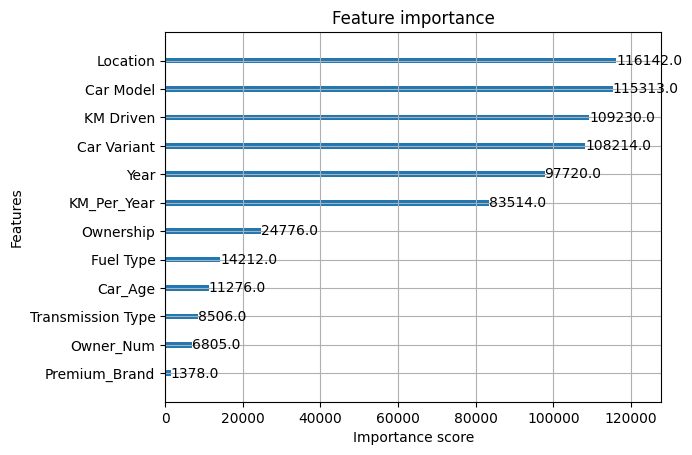

In [ ]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

plot_importance(
    xgb,
    max_num_features=15
)

plt.show()

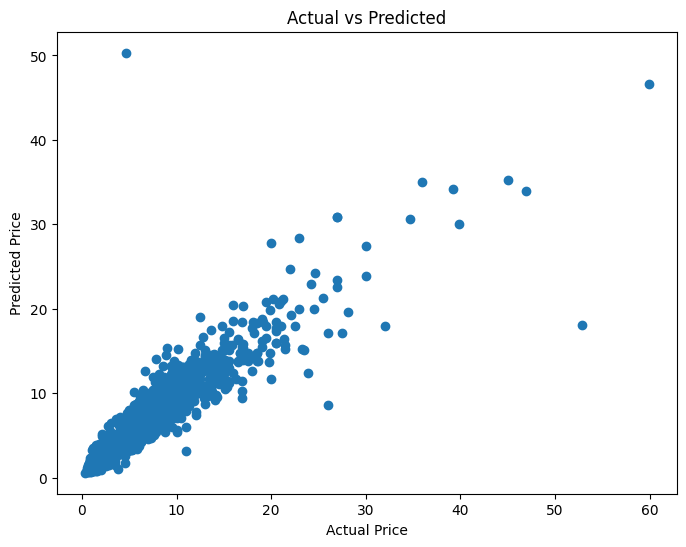

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    xgb_pred
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title(
    "Actual vs Predicted"
)

plt.show()

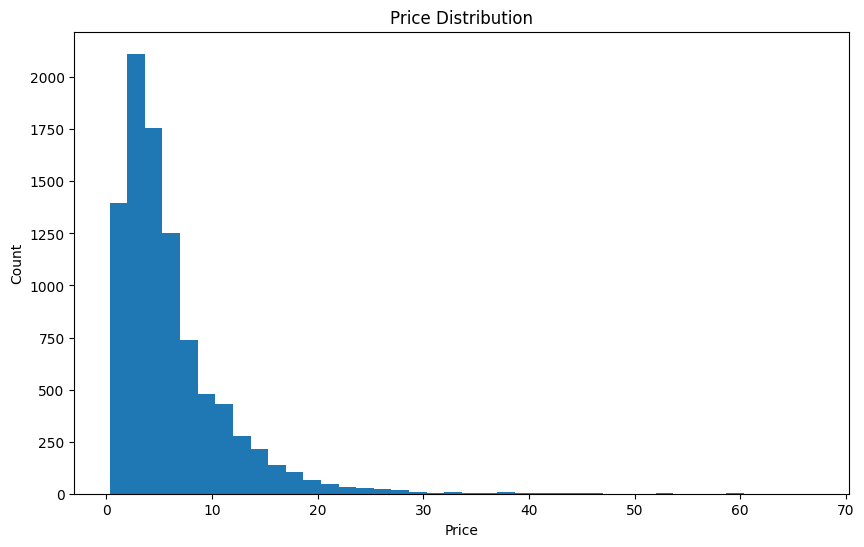

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))

plt.hist(
    df["Price(in Lakhs)"],
    bins=40
)

plt.xlabel("Price")

plt.ylabel("Count")

plt.title(
    "Price Distribution"
)

plt.show()

In [ ]:
import joblib

joblib.dump(
    xgb,
    "cars24_xgboost.pkl"
)

['cars24_xgboost.pkl']

In [ ]:
from google.colab import files
files.download('cars24_xgboost.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>